In [1]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier



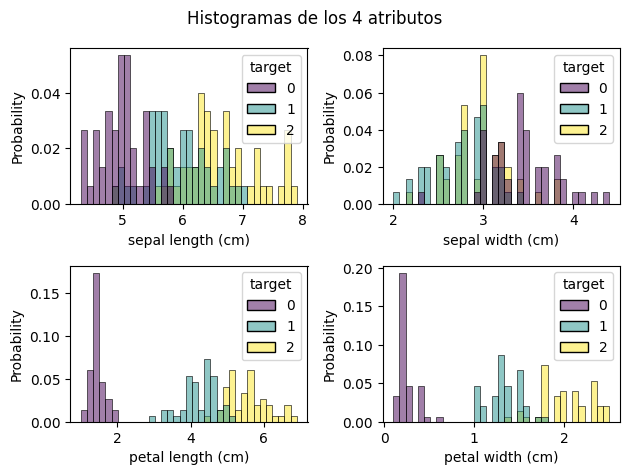

In [3]:

iris = load_iris(as_frame = True)
data = iris.frame
atributos = iris.data
Y = iris.target

iris.target_names
diccionario = dict(zip( [0,1,2], iris.target_names))
#%%
atri = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
#%%
nbins = 35

f, s = plt.subplots(2,2)
plt.suptitle('Histogramas de los 4 atributos', size = 'large')

sns.histplot(data = data, x = 'sepal length (cm)', hue = 'target', bins = nbins, stat = 'probability', ax=s[0,0], palette = 'viridis')
sns.histplot(data = data, x = 'sepal width (cm)', hue = 'target', bins = nbins, stat = 'probability', ax=s[0,1], palette = 'viridis')
sns.histplot(data = data, x = 'petal length (cm)', hue = 'target', bins = nbins, stat = 'probability', ax=s[1,0], palette = 'viridis')
sns.histplot(data = data, x = 'petal width (cm)', hue = 'target', bins = nbins, stat = 'probability', ax=s[1,1], palette = 'viridis')
plt.tight_layout()

In [5]:
def clasificador_iris(fila):
    pet_l = fila['petal length (cm)']
    if pet_l < 2.5:
        clase = 0
    elif pet_l < 4.5:
        clase = 1
    else:
        clase = 2
    return clase
#%%
umbral_0 = 2.5
umbral_1 = 4.5


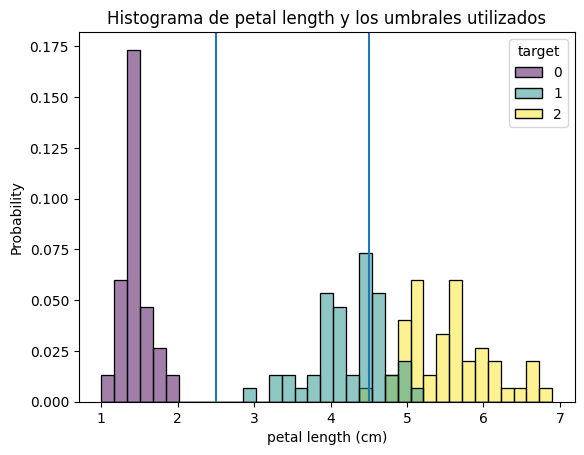

In [6]:
plt.figure()
plt.title('Histograma de petal length y los umbrales utilizados')
sns.histplot(data = data, x = 'petal length (cm)', hue = 'target', bins = nbins, stat = 'probability',  palette = 'viridis')
plt.axvline(x=umbral_0)
plt.axvline(x=umbral_1)
plt.show()

In [ ]:

data_clasif = data.copy()
data_clasif['clase_asignada'] = atributos.apply(lambda row: clasificador_iris(row), axis=1)


In [8]:


clases = set(data['target'])

matriz_confusion = np.zeros((3,3))


for i in range(3):
  for j in range(3):
    filtro = (data_clasif['target']== i) & (data_clasif['clase_asignada'] == j)
    cuenta = len(data_clasif[filtro])
    matriz_confusion[i, j] = cuenta
  
matriz_confusion


array([[50.,  0.,  0.],
       [ 0., 29., 21.],
       [ 0.,  0., 50.]])

In [ ]:
exacti = sum(data_clasif['target']== data_clasif['clase_asignada'])

def exactitud(clasif):
    data_temp = data_clasif.copy()
    data_temp['clase_asignada'] = atributos.apply(lambda row: clasif(row), axis=1)
    suma = sum(data_temp['target']== data_temp['clase_asignada'])
    total = len(data_clasif)
    return suma/total

np.int64(10)

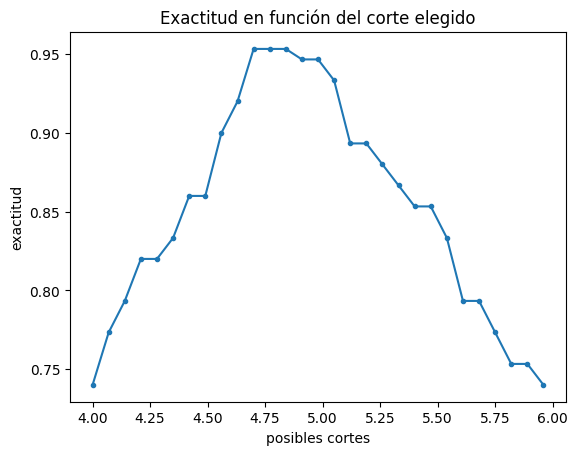

In [24]:
#%%
posibles_cortes = np.arange(start= 4, stop= 6, step=0.07)
exactitudes = []

for c in posibles_cortes:
    def clasificador_temp(fila):
        pet_l = fila['petal length (cm)']
        if pet_l < 2.5:
            clase = 0
        elif pet_l < c:
            clase = 1
        else:
            clase = 2
        return clase
    exact_c = exactitud(clasificador_temp)
    exactitudes.append(exact_c)

plt.plot(posibles_cortes, exactitudes, ".-")
plt.xlabel('posibles cortes')
plt.ylabel('exactitud')
plt.title('Exactitud en función del corte elegido')

max(exactitudes)
np.argmax(exactitudes)


array([2])

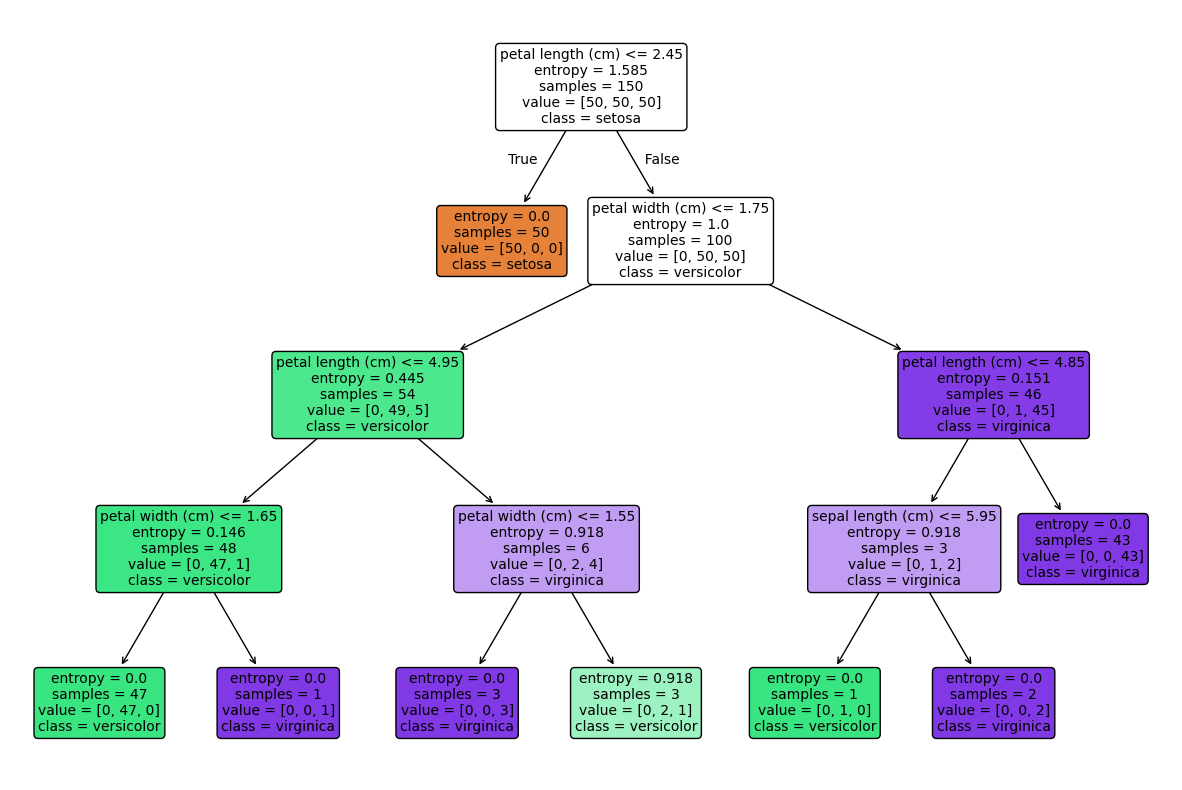

In [ ]:


exactitudes[8]
corte_selec = posibles_cortes[np.argmax(exactitudes)]

X = atributos
Y = data['target']
     
        
clf_info = tree.DecisionTreeClassifier(criterion = "entropy", max_depth= 4)
clf_info = clf_info.fit(X, Y)


plt.figure(figsize= [15,10])
tree.plot_tree(clf_info, feature_names = iris['feature_names'], class_names = iris['target_names'],filled = True, rounded = True, fontsize = 10)


datonuevo= pd.DataFrame([dict(zip(iris['feature_names'], [6.8,3,4.5, 2.15]))])
clf_info.predict(datonuevo)



In [29]:

#%%
# otra forma de ver el arbol
r = tree.export_text(clf_info, feature_names=iris['feature_names'])
print(r)
#%%

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- class: 1
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2

